In [1]:
# =============================================================================
# Zelle 01 – Setup & Datenladen (EDA Modell B, NEU nach Vakuum/Innenluft-Fix)
# =============================================================================
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE

SEED = 42
apply_store44_style()

df_b = pd.read_csv("../data/raw/model_b_raw.csv")

X_B_MERKMALE = ["material_mfr", "dn_ziel", "wandstaerke_soll", "dickentoleranz",
                 "wandtyp", "produktionsgeschwindigkeit_soll", "ovalitaet_anforderung"]
Y_B_MERKMALE = ["schneckendrehzahl", "massetemperatur", "duesenspalt",
                 "vakuumniveau", "innenluftdruck", "kuehlwassertemperatur"]

print(f"Datensatz: {df_b.shape}")
print(f"X_B ({len(X_B_MERKMALE)}): {X_B_MERKMALE}")
print(f"Y_B ({len(Y_B_MERKMALE)}): {Y_B_MERKMALE}")
print(f"\nErste Zeilen:")
df_b.head()

Datensatz: (2000, 14)
X_B (7): ['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'wandtyp', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung']
Y_B (6): ['schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'vakuumniveau', 'innenluftdruck', 'kuehlwassertemperatur']

Erste Zeilen:


,material_mfr,dn_ziel,wandstaerke_soll,dickentoleranz,wandtyp,produktionsgeschwindigkeit_soll,ovalitaet_anforderung,schneckendrehzahl,massetemperatur,duesenspalt,vakuumniveau,innenluftdruck,kuehlwassertemperatur,schmelzfestigkeit_proxy
0,0.760943,104.164565,1.385443,0.055494,einwandig,9.400096,0.441754,33.691143,200.906186,1.434323,80.171432,78.197271,19.783884,0.539057
1,0.492003,158.608859,2.350657,0.295226,doppelwandig,10.168837,0.353945,43.847410,199.855728,2.346622,92.722924,62.177159,19.459041,0.807997
2,0.850090,123.340827,1.836205,0.114787,einwandig,10.907655,0.784632,45.499866,210.933172,1.929061,84.345502,105.947346,16.953516,0.449910
3,0.888113,225.335978,2.589429,0.198277,einwandig,6.963402,0.734473,46.943818,208.291018,2.655661,99.900177,57.771840,21.110659,0.411887
4,0.309793,72.773106,1.553914,0.125063,einwandig,12.279022,0.882630,36.970557,190.000000,1.597350,87.742534,91.287064,19.647650,0.990207


In [2]:
# =============================================================================
# Zelle 02 – Deskriptive Statistik (numerische X_B/Y_B-Merkmale)
# =============================================================================
numerische_merkmale = [c for c in X_B_MERKMALE + Y_B_MERKMALE if c != "wandtyp"]

deskriptiv = df_b[numerische_merkmale].describe().T
deskriptiv["skewness"] = df_b[numerische_merkmale].skew()
deskriptiv["kurtosis"] = df_b[numerische_merkmale].kurt()

shapiro_ergebnisse = []
for col in numerische_merkmale:
    stat, p = stats.shapiro(df_b[col].sample(min(len(df_b), 5000), random_state=SEED))
    shapiro_ergebnisse.append({"merkmal": col, "shapiro_p": round(p, 5), "normalverteilt": p > 0.05})

shapiro_df = pd.DataFrame(shapiro_ergebnisse).set_index("merkmal")
deskriptiv = deskriptiv.join(shapiro_df)

print(deskriptiv.round(3).to_string())
deskriptiv.to_csv("../reports/tables/09_deskriptive_statistik_model_b.csv")

                                  count     mean     std      min      25%      50%      75%      max  skewness  kurtosis  shapiro_p  normalverteilt
material_mfr                     2000.0    0.691   0.196    0.300    0.556    0.696    0.820    1.336     0.095    -0.266      0.000           False
dn_ziel                          2000.0  143.859  61.740   50.000   96.089  132.313  176.674  315.000     0.935     0.479      0.000           False
wandstaerke_soll                 2000.0    2.149   0.515    1.132    1.764    2.056    2.447    3.816     0.771     0.208      0.000           False
dickentoleranz                   2000.0    0.175   0.073    0.050    0.110    0.176    0.236    0.300    -0.015    -1.203      0.000           False
produktionsgeschwindigkeit_soll  2000.0   10.396   2.459    2.460    8.827   10.333   12.001   17.000    -0.052     0.045      0.041           False
ovalitaet_anforderung            2000.0    0.653   0.205    0.300    0.472    0.663    0.832    1.000    -

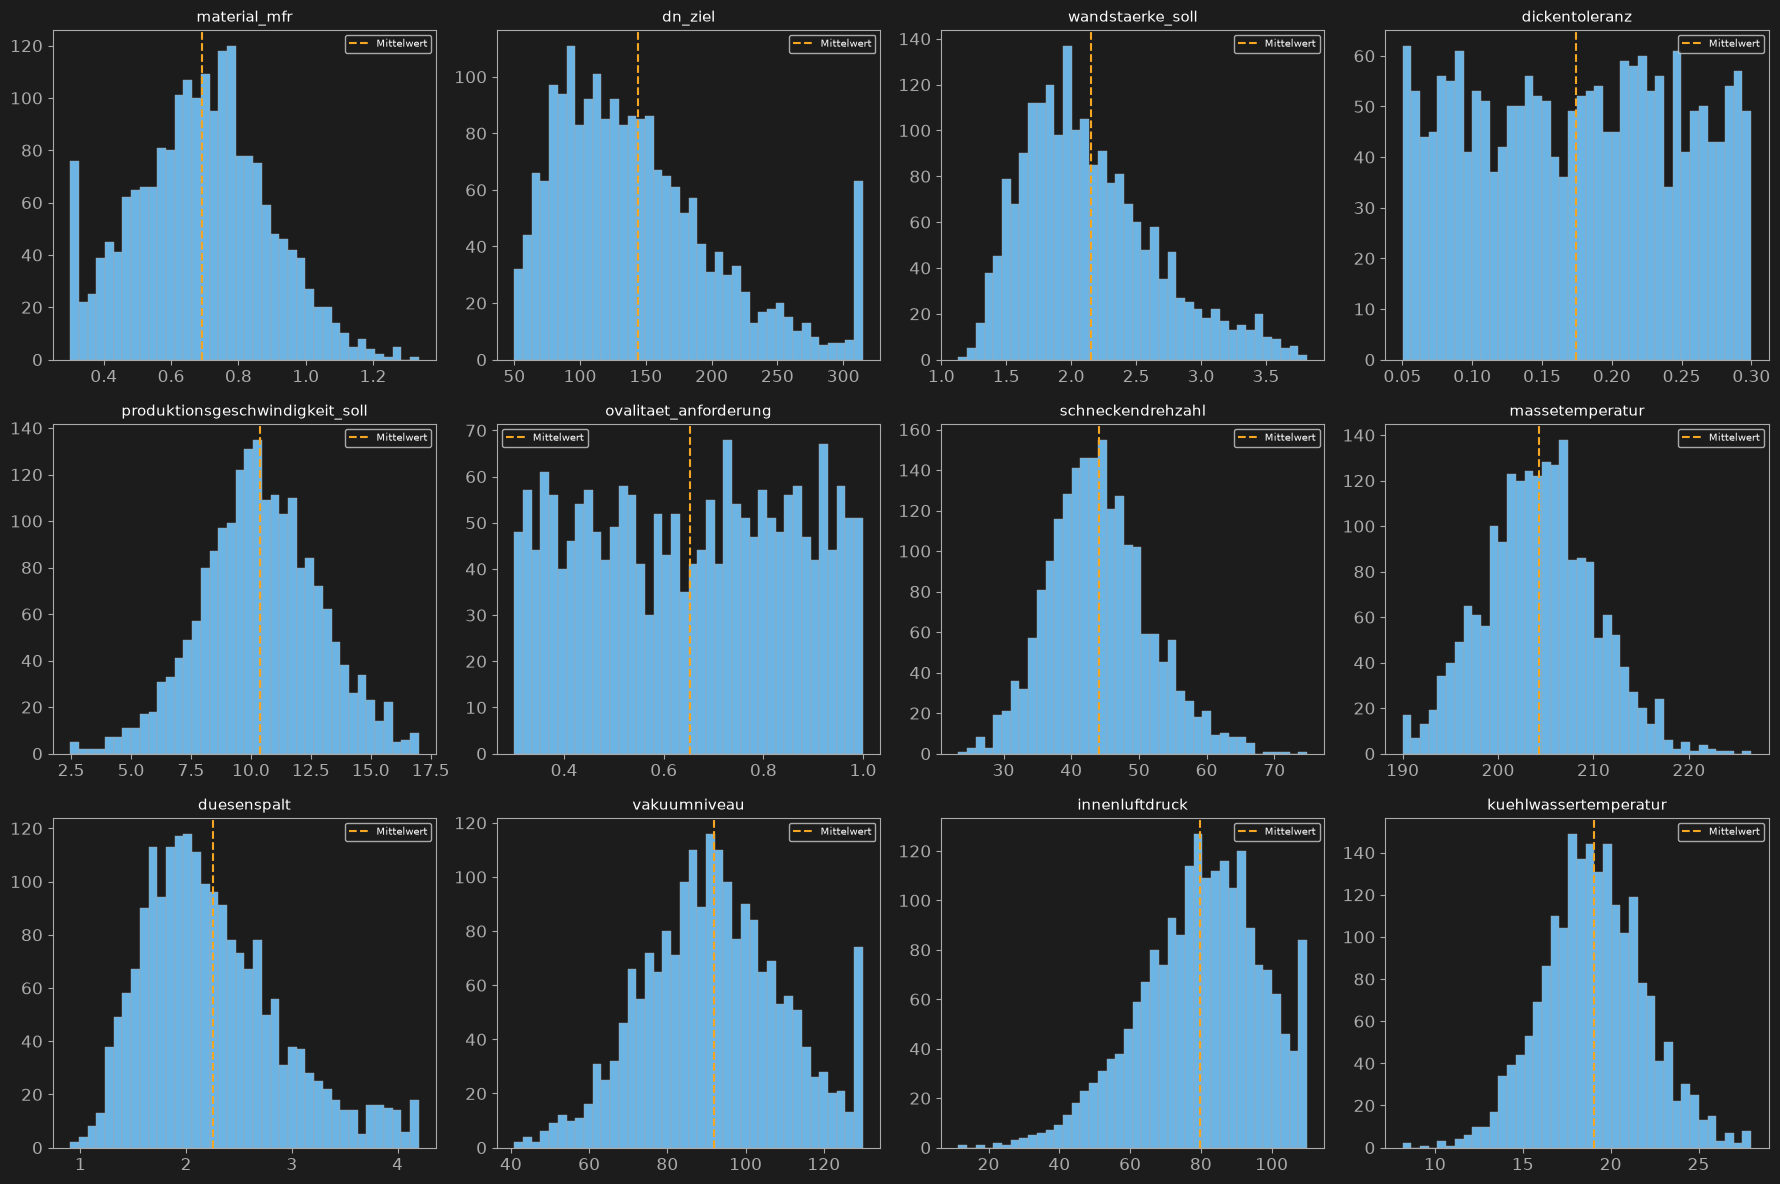

In [3]:
# =============================================================================
# Zelle 03 – Verteilungs-Histogramme aller numerischen X_B/Y_B-Merkmale
# =============================================================================
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, numerische_merkmale):
    ax.hist(df_b[col], bins=40, color=COLOR_BLUE, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GOLD, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

# Leere Subplots ausblenden (12 Slots, 11 Merkmale)
for ax in axes[len(numerische_merkmale):]:
    ax.axis("off")

plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_model_b.png")
plt.show()

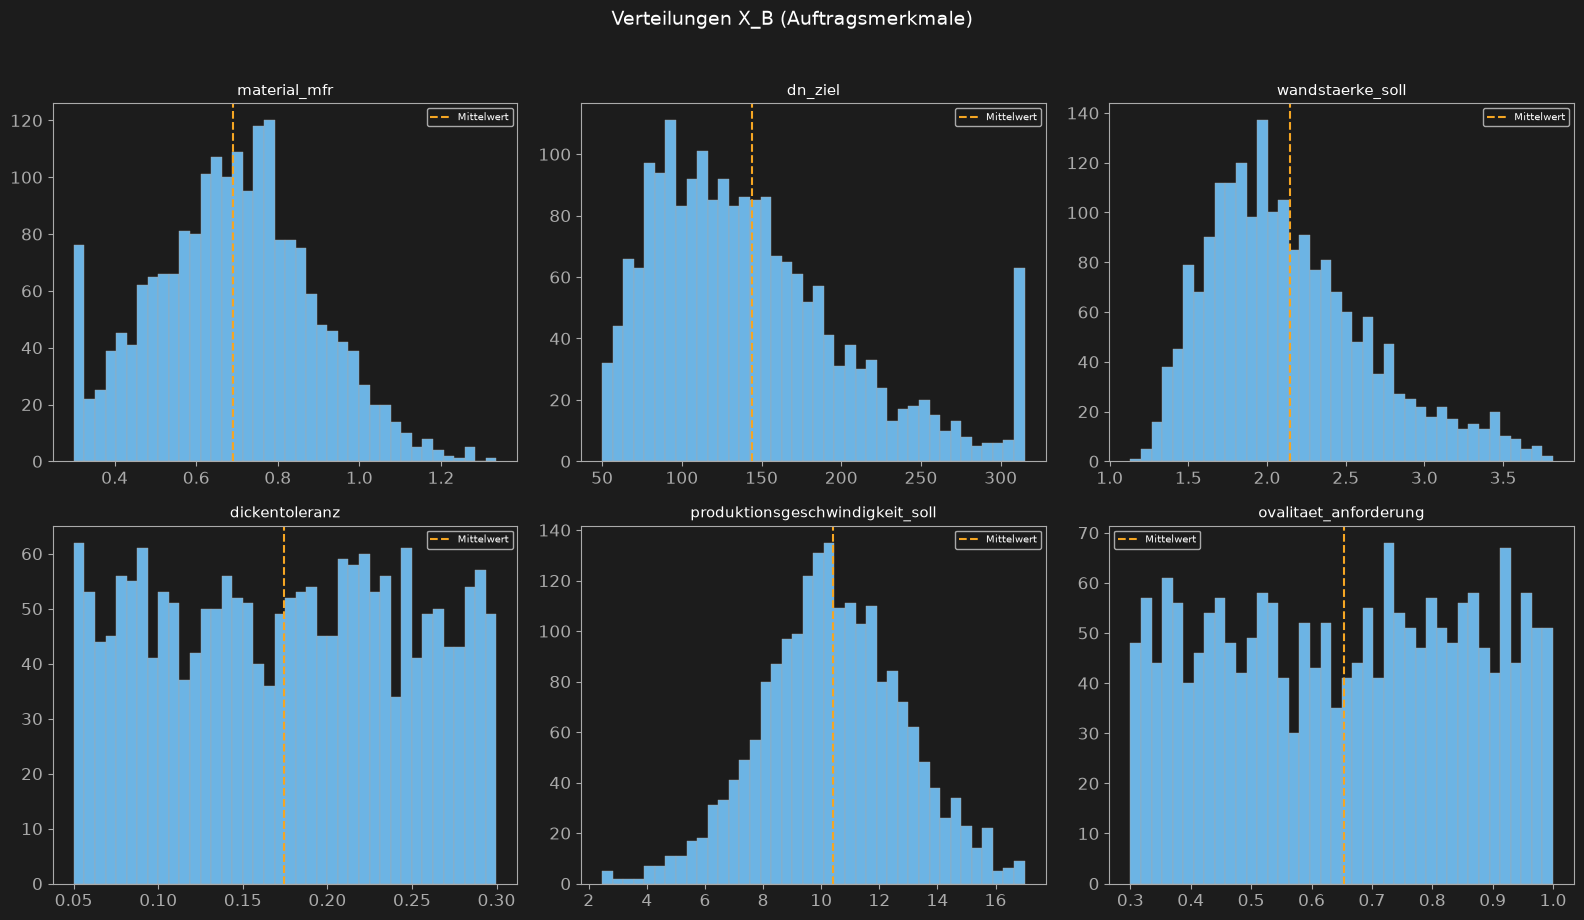

In [4]:
# =============================================================================
# Zelle 03a – Verteilungs-Histogramme X_B (Auftragsmerkmale)
# =============================================================================
x_b_numerisch = [c for c in X_B_MERKMALE if c != "wandtyp"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, x_b_numerisch):
    ax.hist(df_b[col], bins=40, color=COLOR_BLUE, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GOLD, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

for ax in axes[len(x_b_numerisch):]:
    ax.axis("off")

fig.suptitle("Verteilungen X_B (Auftragsmerkmale)", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_x_b.png")
plt.show()

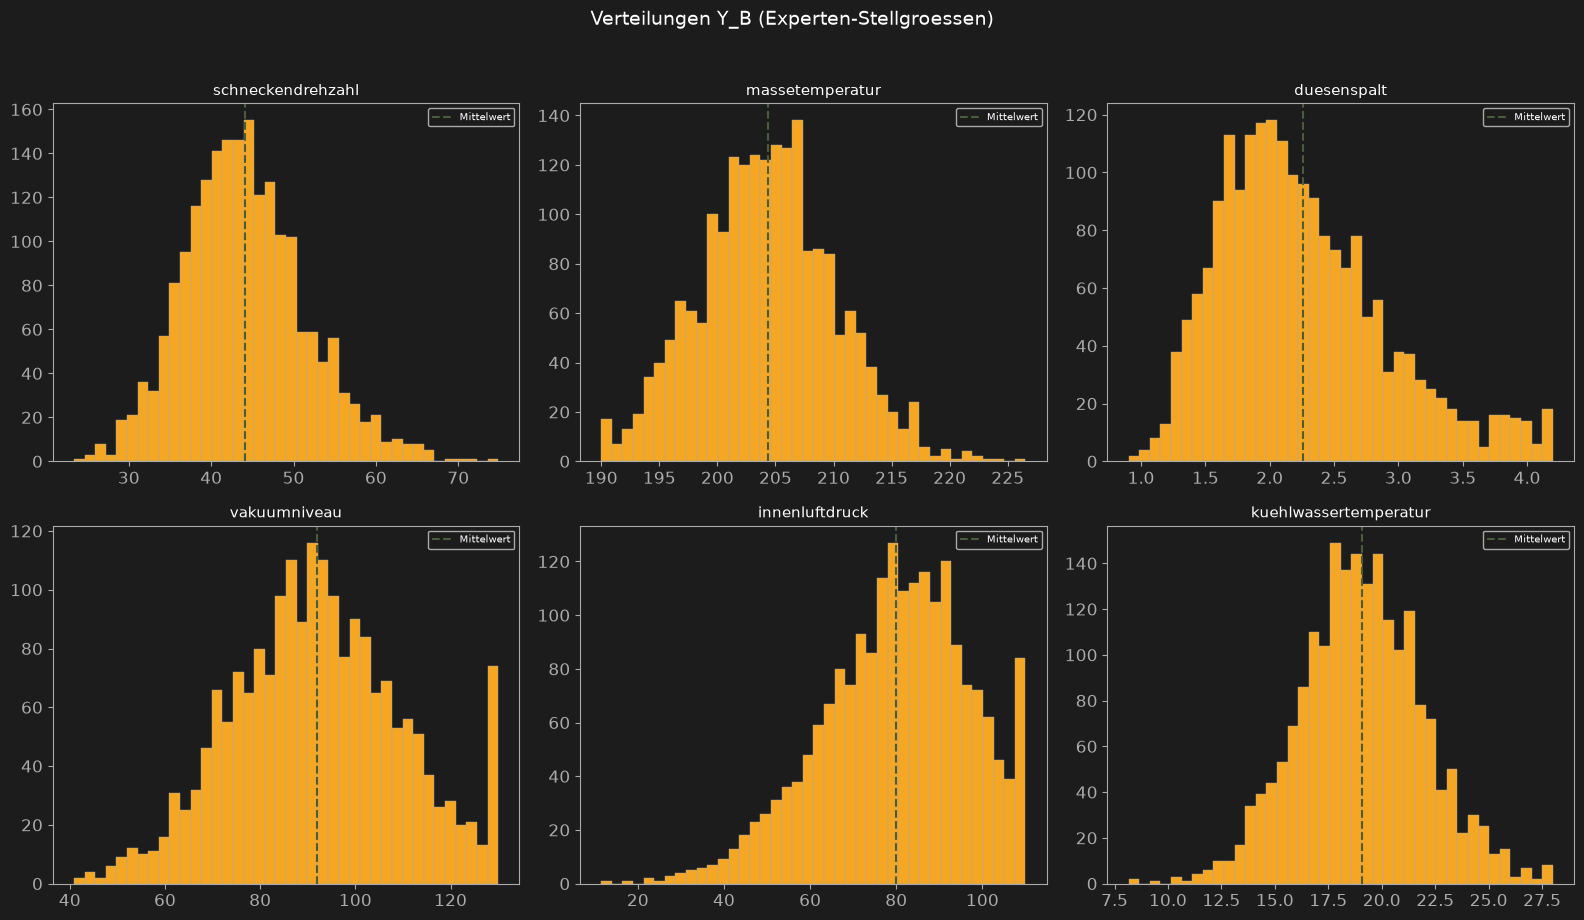

In [5]:
# =============================================================================
# Zelle 03b – Verteilungs-Histogramme Y_B (Experten-Stellgroessen)
# =============================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, Y_B_MERKMALE):
    ax.hist(df_b[col], bins=40, color=COLOR_GOLD, edgecolor=COLOR_TEXT_MUTED, linewidth=0.3)
    ax.axvline(df_b[col].mean(), color=COLOR_GREEN, linestyle="--", linewidth=1.5, label="Mittelwert")
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=7)

for ax in axes[len(Y_B_MERKMALE):]:
    ax.axis("off")

fig.suptitle("Verteilungen Y_B (Experten-Stellgroessen)", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_verteilungen_y_b.png")
plt.show()

## Datenwörterbuch – Modell B (model_b_raw.csv), aktualisiert nach Vakuum/Innenluft-Korrektur

| Spalte | Beschreibung | Einheit | Typ |
|---|---|---|---|
| material_mfr | Schmelzindex der Materialcharge | g/10min | kontinuierlich |
| dn_ziel | Ziel-Nennweite des Rohrs | mm | kontinuierlich |
| wandstaerke_soll | Geforderte Wandstärke | mm | kontinuierlich |
| dickentoleranz | Zulässige Abweichung von der Sollwandstärke | mm | kontinuierlich |
| wandtyp | Rohrkonstruktion | – | kategorial (einwandig/doppelwandig) |
| produktionsgeschwindigkeit_soll | Geforderte Produktionsgeschwindigkeit | m/min | kontinuierlich |
| ovalitaet_anforderung | Zulässige Rundheitsabweichung | % | kontinuierlich |
| schneckendrehzahl | Gewählte Schneckendrehzahl | U/min | kontinuierlich, **Zielgröße (Y_B)** |
| massetemperatur | Gewählte Massetemperatur | °C | kontinuierlich, **Zielgröße (Y_B)** |
| duesenspalt | Gewählter Düsenspalt | mm | kontinuierlich, **Zielgröße (Y_B)** |
| **vakuumniveau** | Gewähltes Vakuumniveau (zieht Schmelzschlauch an Kavität) | mbar | kontinuierlich, **Zielgröße (Y_B)**, **neu** |
| **innenluftdruck** | Gewählter Innenluftdruck (stabilisiert Schmelzschlauch gegen Kollaps) | mbar | kontinuierlich, **Zielgröße (Y_B)**, **neu** |
| kuehlwassertemperatur | Gewählte Kühlwassertemperatur | °C | kontinuierlich, **Zielgröße (Y_B)** |
| schmelzfestigkeit_proxy | Aus MFR abgeleiteter Hilfsindikator (Konstruktionsgröße, kein echtes X_B/Y_B) | – | kontinuierlich, Hilfsvariable |

**X_B (7 Eingabemerkmale):** unverändert

**Y_B (6 Zielgrößen, geändert):** schneckendrehzahl, massetemperatur, duesenspalt, **vakuumniveau, innenluftdruck** (ersetzen kalibrierdruck), kuehlwassertemperatur

**Entfernt:** kalibrierdruck, kalibriermechanismus (fachlich unrealistischer harter DN-Schwellenwert-Schalter, siehe Notebook 08 Korrektur)

In [6]:
# =============================================================================
# Zelle 06 – AP 0.1: Blinde erste Sichtung (wie ein Analyst ohne Vorwissen)
# =============================================================================
print(f"Shape: {df_b.shape}")
print(f"\nSpalten:\n{df_b.columns.tolist()}")
print(f"\nDatentypen:\n{df_b.dtypes}")
df_b.head()

Shape: (2000, 14)

Spalten:
['material_mfr', 'dn_ziel', 'wandstaerke_soll', 'dickentoleranz', 'wandtyp', 'produktionsgeschwindigkeit_soll', 'ovalitaet_anforderung', 'schneckendrehzahl', 'massetemperatur', 'duesenspalt', 'vakuumniveau', 'innenluftdruck', 'kuehlwassertemperatur', 'schmelzfestigkeit_proxy']

Datentypen:
material_mfr                       float64
dn_ziel                            float64
wandstaerke_soll                   float64
dickentoleranz                     float64
wandtyp                             object
produktionsgeschwindigkeit_soll    float64
ovalitaet_anforderung              float64
schneckendrehzahl                  float64
massetemperatur                    float64
duesenspalt                        float64
vakuumniveau                       float64
innenluftdruck                     float64
kuehlwassertemperatur              float64
schmelzfestigkeit_proxy            float64
dtype: object


,material_mfr,dn_ziel,wandstaerke_soll,dickentoleranz,wandtyp,produktionsgeschwindigkeit_soll,ovalitaet_anforderung,schneckendrehzahl,massetemperatur,duesenspalt,vakuumniveau,innenluftdruck,kuehlwassertemperatur,schmelzfestigkeit_proxy
0,0.760943,104.164565,1.385443,0.055494,einwandig,9.400096,0.441754,33.691143,200.906186,1.434323,80.171432,78.197271,19.783884,0.539057
1,0.492003,158.608859,2.350657,0.295226,doppelwandig,10.168837,0.353945,43.847410,199.855728,2.346622,92.722924,62.177159,19.459041,0.807997
2,0.850090,123.340827,1.836205,0.114787,einwandig,10.907655,0.784632,45.499866,210.933172,1.929061,84.345502,105.947346,16.953516,0.449910
3,0.888113,225.335978,2.589429,0.198277,einwandig,6.963402,0.734473,46.943818,208.291018,2.655661,99.900177,57.771840,21.110659,0.411887
4,0.309793,72.773106,1.553914,0.125063,einwandig,12.279022,0.882630,36.970557,190.000000,1.597350,87.742534,91.287064,19.647650,0.990207


In [7]:
# =============================================================================
# Zelle 07 – AP 1.3 + 1.4: Fehlende Werte-Check + IQR-Ausreisser-Analyse
# =============================================================================
print("=== AP 1.3: Fehlende Werte ===")
print(df_b.isna().sum())
print(f"\nDatensatz bewusst vollstaendig gehalten (keine MCAR/MNAR-Luecken "
      f"generiert, im Gegensatz zu Modell A) - Entscheidung getroffen, um "
      f"Fokus auf die X_B->Y_B-Beziehung selbst zu legen.")

print("\n=== AP 1.4: IQR-Ausreisser je numerischer Variable ===")
numerische_merkmale = [c for c in df_b.columns if df_b[c].dtype != "object"]

ausreisser_ergebnisse = []
for col in numerische_merkmale:
    q1, q3 = df_b[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    untere_grenze, obere_grenze = q1 - 1.5*iqr, q3 + 1.5*iqr
    ausreisser = df_b[(df_b[col] < untere_grenze) | (df_b[col] > obere_grenze)]
    ausreisser_ergebnisse.append({
        "merkmal": col, "q1": round(q1,3), "q3": round(q3,3), "iqr": round(iqr,3),
        "untere_grenze": round(untere_grenze,3), "obere_grenze": round(obere_grenze,3),
        "n_ausreisser": len(ausreisser), "anteil_prozent": round(len(ausreisser)/len(df_b)*100, 2)
    })

ausreisser_df = pd.DataFrame(ausreisser_ergebnisse)
print(ausreisser_df.to_string(index=False))
ausreisser_df.to_csv("../reports/tables/09_iqr_ausreisser_model_b.csv", index=False)
print("\nGespeichert: reports/tables/09_iqr_ausreisser_model_b.csv")

=== AP 1.3: Fehlende Werte ===
material_mfr                       0
dn_ziel                            0
wandstaerke_soll                   0
dickentoleranz                     0
wandtyp                            0
produktionsgeschwindigkeit_soll    0
ovalitaet_anforderung              0
schneckendrehzahl                  0
massetemperatur                    0
duesenspalt                        0
vakuumniveau                       0
innenluftdruck                     0
kuehlwassertemperatur              0
schmelzfestigkeit_proxy            0
dtype: int64

Datensatz bewusst vollstaendig gehalten (keine MCAR/MNAR-Luecken generiert, im Gegensatz zu Modell A) - Entscheidung getroffen, um Fokus auf die X_B->Y_B-Beziehung selbst zu legen.

=== AP 1.4: IQR-Ausreisser je numerischer Variable ===
                        merkmal      q1      q3    iqr  untere_grenze  obere_grenze  n_ausreisser  anteil_prozent
                   material_mfr   0.556   0.820  0.264          0.160         1.216   

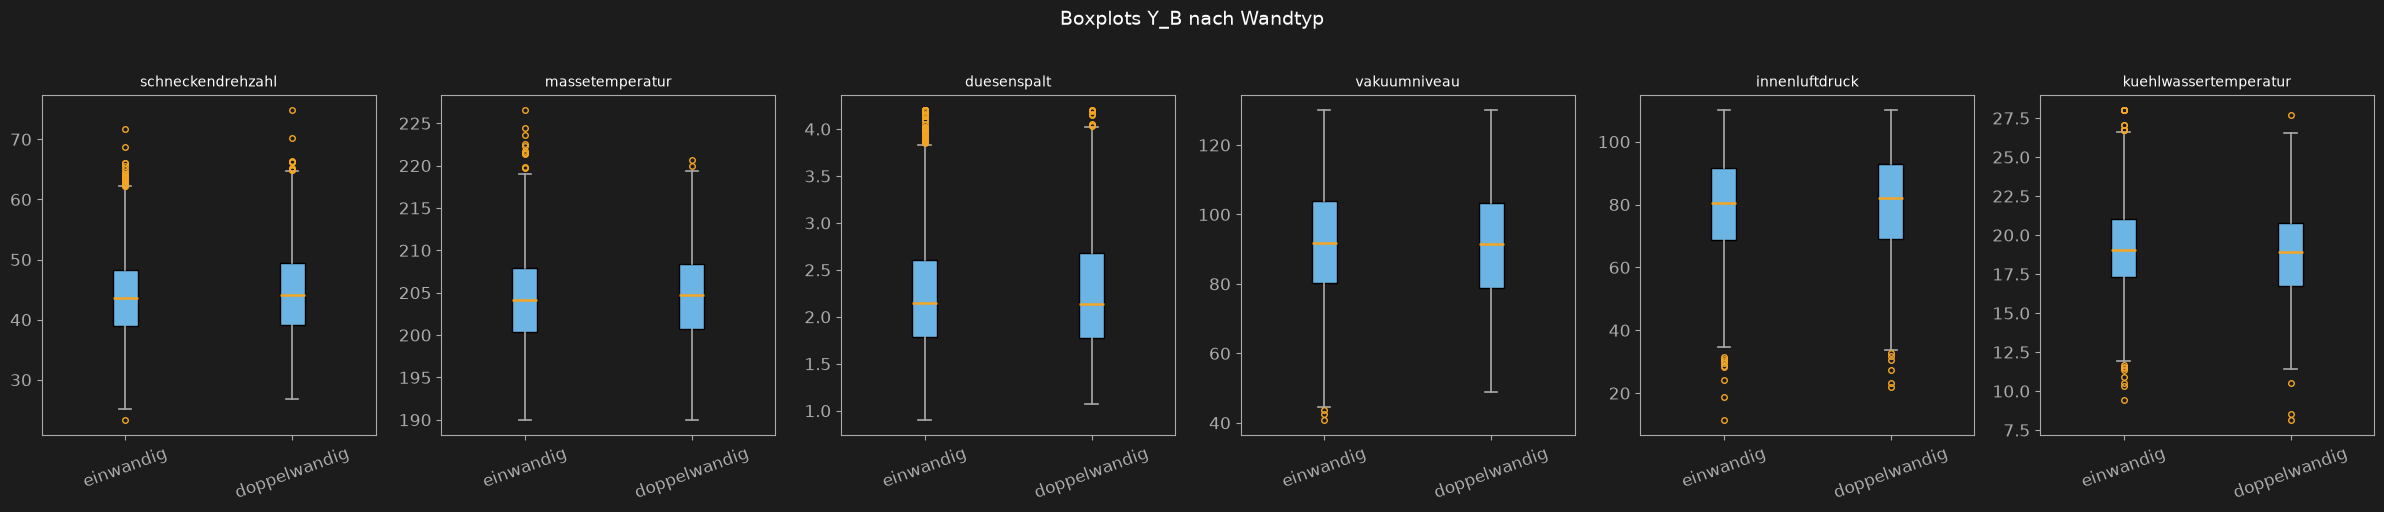

In [8]:
# =============================================================================
# Zelle 08 – AP 2.5: Boxplots Y_B nach Wandtyp
# =============================================================================
# KORREKTUR: "nach Mechanismus"-Zeile entfaellt komplett - kalibriermechanismus
# existiert nicht mehr (siehe Notebook 08 Korrektur: Vakuum/Innenluft sind
# jetzt zwei separate, gleichzeitig wirkende kontinuierliche Groessen statt
# einer kategorialen Schalter-Variable). Grafik auf 6 Y_B-Spalten erweitert.
# =============================================================================

fig, axes = plt.subplots(1, 6, figsize=(24, 5))

for i, y_col in enumerate(Y_B_MERKMALE):
    daten_wandtyp = [df_b[df_b["wandtyp"]==w][y_col].values for w in ["einwandig", "doppelwandig"]]
    bp1 = axes[i].boxplot(daten_wandtyp, tick_labels=["einwandig","doppelwandig"], patch_artist=True, **BOXPLOT_STYLE)
    for box in bp1["boxes"]:
        box.set_facecolor(COLOR_BLUE)
    axes[i].set_title(y_col, fontsize=10)
    axes[i].tick_params(axis="x", rotation=20)

fig.suptitle("Boxplots Y_B nach Wandtyp", fontsize=14, y=1.02)
plt.tight_layout()
save_figure(fig, "../reports/figures/09_boxplots_y_b_nach_wandtyp.png")
plt.show()

In [10]:
# =============================================================================
# Zelle 09 – AP 2.1: Pearson-Korrelationsmatrix berechnen (X_B numerisch x Y_B)
# =============================================================================
x_b_numerisch = ["material_mfr", "dn_ziel", "wandstaerke_soll", "dickentoleranz",
                  "produktionsgeschwindigkeit_soll", "ovalitaet_anforderung"]
pearson_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for x_col in x_b_numerisch:
    for y_col in Y_B_MERKMALE:
        pearson_matrix.loc[x_col, y_col] = df_b[x_col].corr(df_b[y_col], method="pearson")
print(pearson_matrix.round(3).to_string())
pearson_matrix.to_csv("../reports/tables/09_pearson_korrelation_x_b_y_b.csv")

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                -0.056            0.352       -0.109        -0.251           0.187                 -0.177
dn_ziel                                      0.740            0.548        0.943         0.551          -0.636                 -0.081
wandstaerke_soll                             0.709            0.534        0.972         0.559          -0.637                 -0.079
dickentoleranz                               0.002           -0.021       -0.025         0.026           0.051                 -0.021
produktionsgeschwindigkeit_soll              0.141           -0.079       -0.419        -0.247           0.553                 -0.397
ovalitaet_anforderung                        0.006           -0.034        0.014         0.004          -0.005                 -0.004


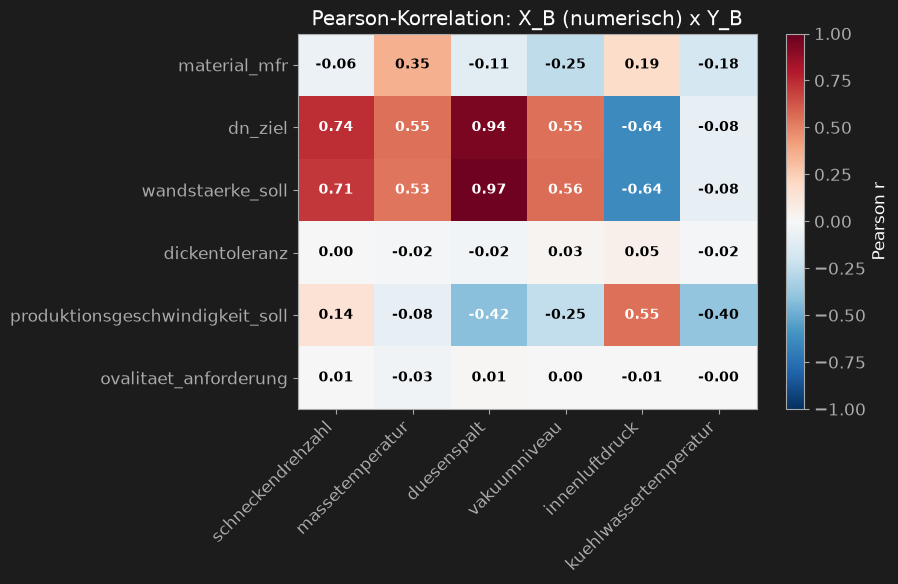

In [11]:
# =============================================================================
# Zelle 09b – AP 2.1: Pearson-Korrelation Heatmap (Textfarbe je nach Zellwert)
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pearson_matrix.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(Y_B_MERKMALE)):
        wert = pearson_matrix.values[i, j]
        textfarbe = "black" if abs(wert) < 0.4 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=10, fontweight="bold")
plt.colorbar(im, label="Pearson r")
plt.title("Pearson-Korrelation: X_B (numerisch) x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_pearson_heatmap_x_b_y_b.png")
plt.show()

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                -0.045            0.337       -0.106        -0.252           0.183                 -0.177
dn_ziel                                      0.695            0.521        0.924         0.514          -0.585                 -0.074
wandstaerke_soll                             0.662            0.510        0.965         0.526          -0.590                 -0.076
dickentoleranz                               0.009           -0.019       -0.021         0.025           0.047                 -0.029
produktionsgeschwindigkeit_soll              0.151           -0.081       -0.391        -0.233           0.532                 -0.371
ovalitaet_anforderung                        0.009           -0.031        0.009         0.003          -0.001                 -0.003


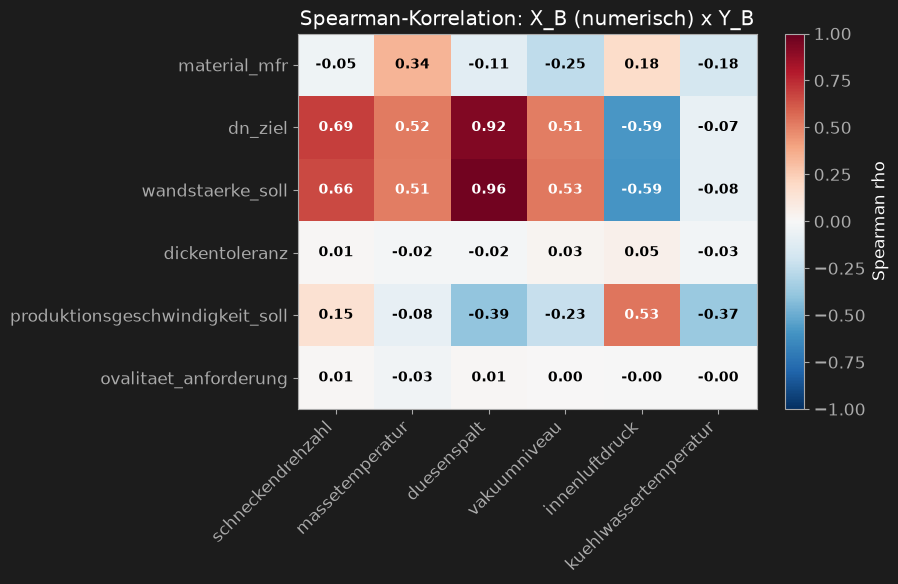


=== Groesste Abweichungen Pearson vs. Spearman (Hinweis auf Nichtlinearitaet) ===
dn_ziel           innenluftdruck       0.050711
wandstaerke_soll  schneckendrehzahl    0.047379
                  innenluftdruck       0.046806
dn_ziel           schneckendrehzahl    0.044803
                  vakuumniveau         0.037135
dtype: float64


In [13]:
# =============================================================================
# Zelle 10 – AP 2.2: Spearman-Korrelationsmatrix (X_B numerisch x Y_B)
# =============================================================================
# Ergaenzt Pearson (nur lineare Zusammenhaenge) um monotone, auch
# nichtlineare Beziehungen - relevant v.a. fuer kalibrierdruck, wo der
# Formluft/Vakuum-Sprung vermutlich von Spearman staerker erfasst wird.
# =============================================================================

spearman_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for x_col in x_b_numerisch:
    for y_col in Y_B_MERKMALE:
        spearman_matrix.loc[x_col, y_col] = df_b[x_col].corr(df_b[y_col], method="spearman")

print(spearman_matrix.round(3).to_string())
spearman_matrix.to_csv("../reports/tables/09_spearman_korrelation_x_b_y_b.csv")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(spearman_matrix.values.astype(float), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(Y_B_MERKMALE)):
        wert = spearman_matrix.values[i, j]
        textfarbe = "black" if abs(wert) < 0.4 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=10, fontweight="bold")
plt.colorbar(im, label="Spearman rho")
plt.title("Spearman-Korrelation: X_B (numerisch) x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_spearman_heatmap_x_b_y_b.png")
plt.show()

# --- Direkter Vergleich Pearson vs. Spearman: wo weichen sie am staerksten ab? ---
differenz = (spearman_matrix.astype(float) - pearson_matrix.astype(float)).abs()
print("\n=== Groesste Abweichungen Pearson vs. Spearman (Hinweis auf Nichtlinearitaet) ===")
print(differenz.stack().sort_values(ascending=False).head(5))

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                 0.000            0.082        0.000         0.036           0.012                  0.025
dn_ziel                                      0.393            0.204        1.025         0.155           0.230                  0.042
wandstaerke_soll                             0.394            0.182        1.407         0.198           0.236                  0.013
dickentoleranz                               0.000            0.000        0.000         0.008           0.007                  0.000
produktionsgeschwindigkeit_soll              0.060            0.022        0.102         0.014           0.184                  0.091
ovalitaet_anforderung                        0.006            0.000        0.000         0.000           0.013                  0.000


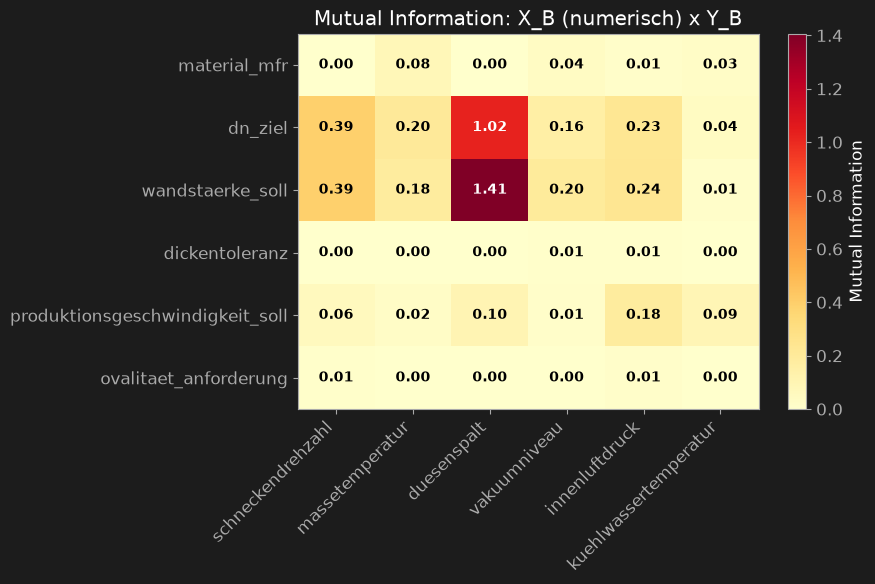


=== Vakuumniveau: Vergleich der drei Methoden ===
                                 pearson_abs  spearman_abs  mutual_info
material_mfr                           0.251         0.252        0.036
dn_ziel                                0.551         0.514        0.155
wandstaerke_soll                       0.559         0.526        0.198
dickentoleranz                         0.026         0.025        0.008
produktionsgeschwindigkeit_soll        0.247         0.233        0.014
ovalitaet_anforderung                  0.004         0.003        0.000

=== Innenluftdruck: Vergleich der drei Methoden ===
                                 pearson_abs  spearman_abs  mutual_info
material_mfr                           0.187         0.183        0.012
dn_ziel                                0.636         0.585        0.230
wandstaerke_soll                       0.637         0.590        0.236
dickentoleranz                         0.051         0.047        0.007
produktionsgeschwindigkeit_soll 

In [16]:
# =============================================================================
# Zelle 11 – AP 2.3: Mutual Information (X_B numerisch x Y_B)
# =============================================================================
# Erfasst beliebige statistische Abhaengigkeit, auch nicht-monotone
# Zusammenhaenge. KORREKTUR: alter Vergleichsblock referenzierte die nicht
# mehr existierende Spalte "kalibrierdruck" - ersetzt durch Vergleich fuer
# beide neuen Druckgroessen (vakuumniveau, innenluftdruck).
# =============================================================================
from sklearn.feature_selection import mutual_info_regression

mi_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for y_col in Y_B_MERKMALE:
    mi_werte = mutual_info_regression(df_b[x_b_numerisch], df_b[y_col], random_state=SEED)
    mi_matrix[y_col] = mi_werte

print(mi_matrix.round(3).to_string())
mi_matrix.to_csv("../reports/tables/09_mutual_information_x_b_y_b.csv")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(mi_matrix.values.astype(float), cmap="YlOrRd", vmin=0, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(Y_B_MERKMALE)):
        wert = mi_matrix.values[i, j]
        textfarbe = "black" if wert < mi_matrix.values.max()*0.5 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=10, fontweight="bold")
plt.colorbar(im, label="Mutual Information")
plt.title("Mutual Information: X_B (numerisch) x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_mutual_information_heatmap.png")
plt.show()

# --- Vergleich: MI vs. Pearson/Spearman fuer vakuumniveau UND innenluftdruck ---
print("\n=== Vakuumniveau: Vergleich der drei Methoden ===")
vergleich_vakuum = pd.DataFrame({
    "pearson_abs": pearson_matrix["vakuumniveau"].astype(float).abs(),
    "spearman_abs": spearman_matrix["vakuumniveau"].astype(float).abs(),
    "mutual_info": mi_matrix["vakuumniveau"],
})
print(vergleich_vakuum.round(3).to_string())

print("\n=== Innenluftdruck: Vergleich der drei Methoden ===")
vergleich_innenluft = pd.DataFrame({
    "pearson_abs": pearson_matrix["innenluftdruck"].astype(float).abs(),
    "spearman_abs": spearman_matrix["innenluftdruck"].astype(float).abs(),
    "mutual_info": mi_matrix["innenluftdruck"],
})
print(vergleich_innenluft.round(3).to_string())

In [18]:
# =============================================================================
# Zelle 12 – AP 2.4: Kruskal-Wallis-Test (Wandtyp x Y_B)
# =============================================================================
# KORREKTUR: nur noch "wandtyp" als kategoriale Gruppierungsvariable -
# kalibriermechanismus existiert nicht mehr (Vakuum/Innenluft sind jetzt
# kontinuierliche, gleichzeitig wirkende Groessen, keine Kategorie).
# Formale statistische Absicherung der Boxplot-Beobachtungen aus Zelle 08.
# =============================================================================
kw_ergebnisse = []
gruppen_werte = df_b["wandtyp"].unique()
for y_col in Y_B_MERKMALE:
    gruppen_daten = [df_b.loc[df_b["wandtyp"]==g, y_col].values for g in gruppen_werte]
    stat, p = stats.kruskal(*gruppen_daten)
    kw_ergebnisse.append({
        "gruppierung": "wandtyp", "y_merkmal": y_col,
        "h_statistik": round(stat, 2), "p_wert": round(p, 5), "signifikant": p < 0.05
    })

kw_df = pd.DataFrame(kw_ergebnisse)
print(kw_df.to_string(index=False))
kw_df.to_csv("../reports/tables/09_kruskal_wallis_model_b.csv", index=False)

gruppierung             y_merkmal  h_statistik  p_wert  signifikant
    wandtyp     schneckendrehzahl         4.57 0.03261         True
    wandtyp       massetemperatur         1.77 0.18389        False
    wandtyp           duesenspalt         0.31 0.57554        False
    wandtyp          vakuumniveau         0.66 0.41740        False
    wandtyp        innenluftdruck         1.42 0.23266        False
    wandtyp kuehlwassertemperatur         3.43 0.06405        False


In [19]:
# =============================================================================
# Zelle 13 – AP 2.6: Einzelmerkmal-R² je X_B->Y_B-Paar (Lookup-Tabellen-Check)
# =============================================================================
# Beantwortet die urspruengliche Nutzerfrage: reicht ein einzelnes Merkmal
# (einfache lineare Regression) zur Vorhersage aus, oder braucht es
# mehrere Merkmale/nichtlineare Modelle fuer echten ML-Mehrwert?
# R² nahe 1.0 bei einem Einzelmerkmal = nahe an trivialem Lookup.
# =============================================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

r2_matrix = pd.DataFrame(index=x_b_numerisch, columns=Y_B_MERKMALE, dtype=float)
for x_col in x_b_numerisch:
    for y_col in Y_B_MERKMALE:
        X_einzeln = df_b[[x_col]].values
        y_ziel = df_b[y_col].values
        modell = LinearRegression().fit(X_einzeln, y_ziel)
        r2_matrix.loc[x_col, y_col] = r2_score(y_ziel, modell.predict(X_einzeln))

print(r2_matrix.round(3).to_string())
r2_matrix.to_csv("../reports/tables/09_einzelmerkmal_r2_model_b.csv")

# --- Bestes Einzelmerkmal je Y_B, zur Interpretation ---
print("\n=== Bestes einzelnes X_B-Merkmal je Y_B (nach R²) ===")
for y_col in Y_B_MERKMALE:
    bestes_merkmal = r2_matrix[y_col].astype(float).idxmax()
    bester_r2 = r2_matrix[y_col].astype(float).max()
    einordnung = "nahe Lookup" if bester_r2 > 0.85 else ("moderat erklaerbar" if bester_r2 > 0.4 else "schwach, ML-Mehrwert noetig")
    print(f"  {y_col:22s} <- {bestes_merkmal:25s} (R²={bester_r2:.3f}, {einordnung})")

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                 0.003            0.124        0.012         0.063           0.035                  0.031
dn_ziel                                      0.547            0.300        0.889         0.304           0.405                  0.007
wandstaerke_soll                             0.503            0.285        0.945         0.312           0.405                  0.006
dickentoleranz                               0.000            0.000        0.001         0.001           0.003                  0.000
produktionsgeschwindigkeit_soll              0.020            0.006        0.175         0.061           0.306                  0.157
ovalitaet_anforderung                        0.000            0.001        0.000         0.000           0.000                  0.000

=== Bestes einzelnes X_B-Merkmal je Y_B (nach R²) ===
  schne

                                 schneckendrehzahl  massetemperatur  duesenspalt  vakuumniveau  innenluftdruck  kuehlwassertemperatur
material_mfr                                 0.023            0.231        0.011         0.158           0.103                  0.154
dn_ziel                                      0.582            0.259        0.011         0.154           0.293                  0.153
wandstaerke_soll                             0.074            0.224        0.954         0.375           0.254                  0.137
dickentoleranz                               0.025            0.077        0.009         0.099           0.076                  0.124
produktionsgeschwindigkeit_soll              0.267            0.120        0.007         0.100           0.192                  0.302
ovalitaet_anforderung                        0.026            0.081        0.007         0.102           0.074                  0.116
wandtyp_einwandig                            0.003            

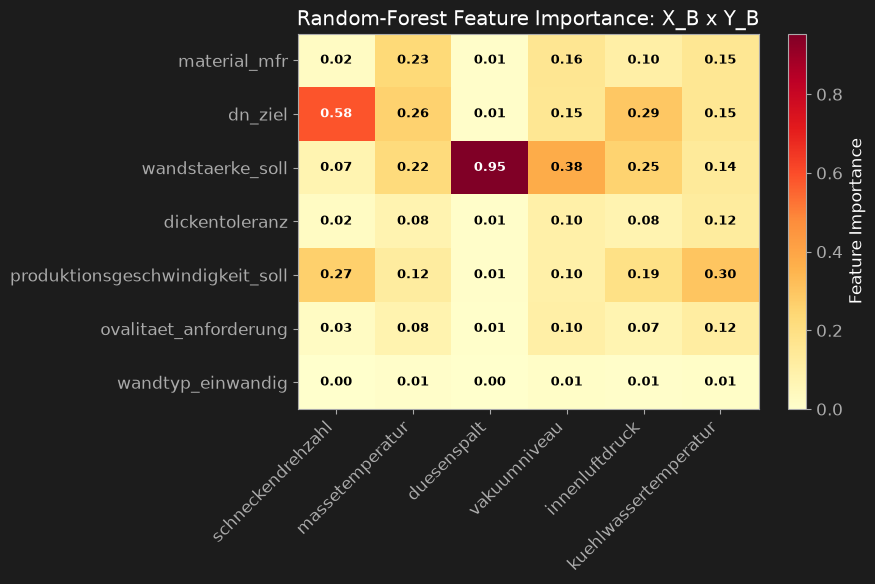

In [20]:
# =============================================================================
# Zelle 14 – AP 2.7: Feature Importance (Random-Forest-Baseline, alle X_B gleichzeitig)
# =============================================================================
# Ergaenzt den Einzelmerkmal-R²-Check (Zelle 13): beruecksichtigt
# Interaktionen zwischen mehreren X_B-Merkmalen gleichzeitig, inkl.
# kategorialer Merkmale (wandtyp, kalibriermechanismus als Dummies).
# =============================================================================
from sklearn.ensemble import RandomForestRegressor

X_B_ALLE = pd.get_dummies(df_b[X_B_MERKMALE], columns=["wandtyp"], drop_first=True)
# kalibriermechanismus bewusst NICHT hier, da er direkt aus dn_ziel abgeleitet
# ist (deterministische Funktion) - waere Leakage der eigenen Zielableitung
# in einigen Y_B-Formeln zu inkludieren; hier nur echte X_B-Auftragsmerkmale

importance_matrix = pd.DataFrame(index=X_B_ALLE.columns, columns=Y_B_MERKMALE, dtype=float)
for y_col in Y_B_MERKMALE:
    rf = RandomForestRegressor(n_estimators=200, random_state=SEED)
    rf.fit(X_B_ALLE, df_b[y_col])
    importance_matrix[y_col] = rf.feature_importances_

print(importance_matrix.round(3).to_string())
importance_matrix.to_csv("../reports/tables/09_feature_importance_rf_model_b.csv")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(importance_matrix.values.astype(float), cmap="YlOrRd", vmin=0, aspect="auto")
ax.set_xticks(range(len(Y_B_MERKMALE)))
ax.set_xticklabels(Y_B_MERKMALE, rotation=45, ha="right")
ax.set_yticks(range(len(X_B_ALLE.columns)))
ax.set_yticklabels(X_B_ALLE.columns)
for i in range(len(X_B_ALLE.columns)):
    for j in range(len(Y_B_MERKMALE)):
        wert = importance_matrix.values[i, j]
        textfarbe = "black" if wert < importance_matrix.values.max()*0.5 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=9, fontweight="bold")
plt.colorbar(im, label="Feature Importance")
plt.title("Random-Forest Feature Importance: X_B x Y_B")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_feature_importance_heatmap.png")
plt.show()

                                 material_mfr  dn_ziel  wandstaerke_soll  dickentoleranz  produktionsgeschwindigkeit_soll  ovalitaet_anforderung
material_mfr                            1.000   -0.055            -0.046          -0.002                           -0.000                 -0.029
dn_ziel                                -0.055    1.000             0.957          -0.027                           -0.454                  0.011
wandstaerke_soll                       -0.046    0.957             1.000          -0.023                           -0.437                  0.017
dickentoleranz                         -0.002   -0.027            -0.023           1.000                            0.043                 -0.022
produktionsgeschwindigkeit_soll        -0.000   -0.454            -0.437           0.043                            1.000                  0.013
ovalitaet_anforderung                  -0.029    0.011             0.017          -0.022                            0.013         

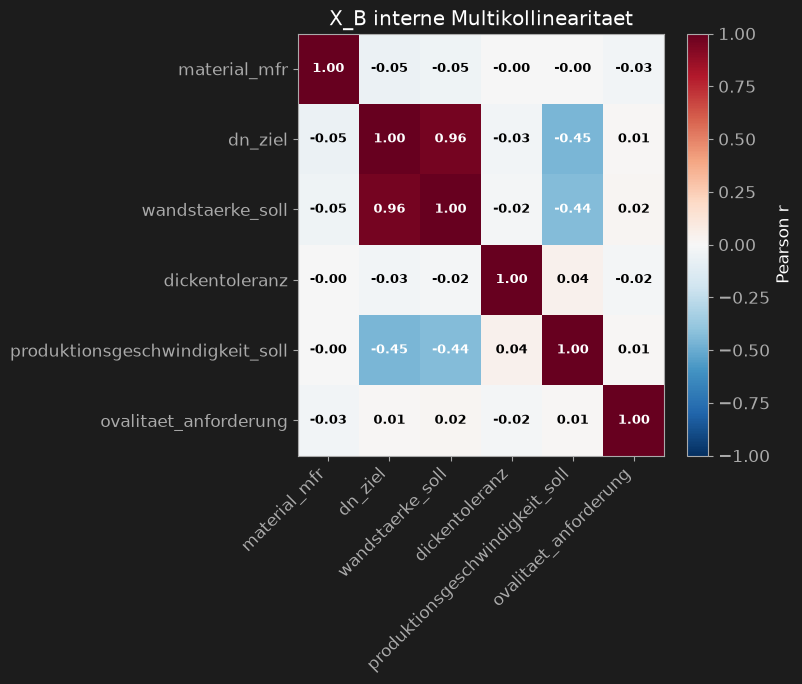


=== Auffaellig hohe Korrelationen (|r| > 0.5) ===
  dn_ziel <-> wandstaerke_soll: r=0.957


In [22]:
# =============================================================================
# Zelle 16 – AP 2.8: X_B interne Multikollinearitaet (nur numerische Merkmale)
# =============================================================================
# Relevant fuer spaetere Preprocessing-Entscheidungen: stark korrelierte
# X_B-Merkmale koennten bei linearen Modellen zu Instabilitaet fuehren
# (aehnlich dem Dummy-Variable-Trap-Prinzip aus Modell A), oder Redundanz
# aufzeigen, die Feature-Reduktion nahelegt.
# =============================================================================
x_b_korrelation = df_b[x_b_numerisch].corr(method="pearson")

print(x_b_korrelation.round(3).to_string())
x_b_korrelation.to_csv("../reports/tables/09_x_b_multikollinearitaet.csv")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(x_b_korrelation.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(x_b_numerisch)))
ax.set_xticklabels(x_b_numerisch, rotation=45, ha="right")
ax.set_yticks(range(len(x_b_numerisch)))
ax.set_yticklabels(x_b_numerisch)
for i in range(len(x_b_numerisch)):
    for j in range(len(x_b_numerisch)):
        wert = x_b_korrelation.values[i, j]
        textfarbe = "black" if abs(wert) < 0.4 else "white"
        ax.text(j, i, f"{wert:.2f}", ha="center", va="center", color=textfarbe, fontsize=9, fontweight="bold")
plt.colorbar(im, label="Pearson r")
plt.title("X_B interne Multikollinearitaet")
plt.tight_layout()
save_figure(fig, "../reports/figures/09_x_b_multikollinearitaet_heatmap.png")
plt.show()

# --- Auffaellig hohe Paare markieren (|r| > 0.5, ausser Diagonale) ---
print("\n=== Auffaellig hohe Korrelationen (|r| > 0.5) ===")
for i in range(len(x_b_numerisch)):
    for j in range(i+1, len(x_b_numerisch)):
        r = x_b_korrelation.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {x_b_numerisch[i]} <-> {x_b_numerisch[j]}: r={r:.3f}")

=== Erklaerte Varianz je Hauptkomponente ===
  PC1:  37.9% (kumulativ:  37.9%)
  PC2:  17.2% (kumulativ:  55.1%)
  PC3:  16.8% (kumulativ:  71.9%)
  PC4:  16.0% (kumulativ:  87.9%)
  PC5:  11.4% (kumulativ:  99.3%)
  PC6:   0.7% (kumulativ: 100.0%)

=== Ladungen PC1 und PC2 ===
                                   PC1    PC2
material_mfr                    -0.050 -0.589
dn_ziel                          0.634 -0.007
wandstaerke_soll                 0.630 -0.008
dickentoleranz                  -0.040 -0.321
produktionsgeschwindigkeit_soll -0.443  0.091
ovalitaet_anforderung            0.011  0.736


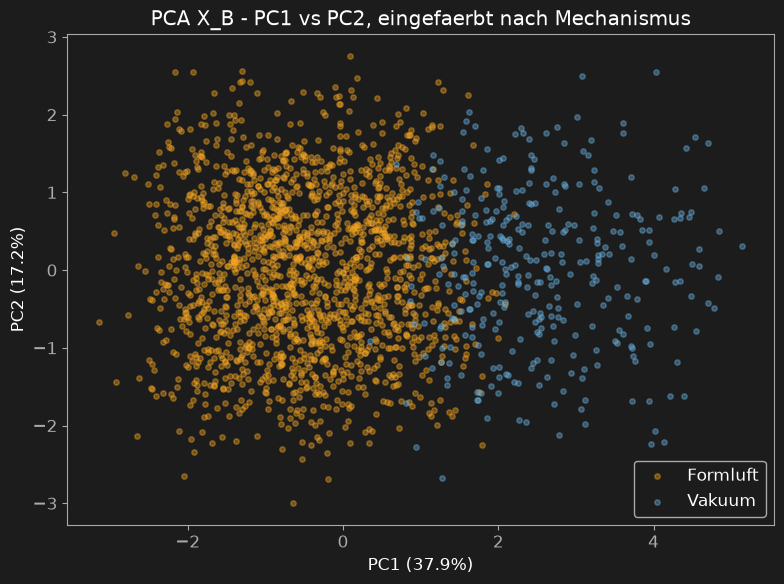

In [ ]:
# =============================================================================
# Zelle 17 – AP 3: PCA auf X_B (numerisch, standardisiert)
# =============================================================================
# Prueft, ob wie bei Modell A ein dominanter "Baugroessen-Faktor" auftritt -
# angesichts der hohen dn_ziel<->wandstaerke_soll-Korrelation (Zelle 16)
# zu erwarten.
# =============================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_b_scaled = StandardScaler().fit_transform(df_b[x_b_numerisch])
pca_b = PCA(random_state=SEED)
X_b_pca = pca_b.fit_transform(X_b_scaled)

erklaerte_varianz = pca_b.explained_variance_ratio_
kumulativ = np.cumsum(erklaerte_varianz)

print("=== Erklaerte Varianz je Hauptkomponente ===")
for i, (ev, kum) in enumerate(zip(erklaerte_varianz, kumulativ)):
    print(f"  PC{i+1}: {ev*100:5.1f}% (kumulativ: {kum*100:5.1f}%)")

# --- Ladungen (Loadings) der ersten 2 Komponenten ---
loadings = pd.DataFrame(pca_b.components_[:2].T, index=x_b_numerisch, columns=["PC1", "PC2"])
print("\n=== Ladungen PC1 und PC2 ===")
print(loadings.round(3).to_string())
loadings.to_csv("../reports/tables/09_pca_ladungen_model_b.csv")

# --- Scatter PC1 vs PC2, eingefaerbt nach kalibriermechanismus ---
fig, ax = plt.subplots(figsize=(8, 6))
for mech, farbe in zip(["Formluft", "Vakuum"], [COLOR_GOLD, COLOR_BLUE]):
    maske = df_b["kalibriermechanismus"] == mech
    ax.scatter(X_b_pca[maske, 0], X_b_pca[maske, 1], alpha=0.4, s=15, color=farbe, label=mech)
ax.set_xlabel(f"PC1 ({erklaerte_varianz[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({erklaerte_varianz[1]*100:.1f}%)")
ax.set_title("PCA X_B - PC1 vs PC2, eingefaerbt nach Mechanismus")
ax.legend()
plt.tight_layout()
save_figure(fig, "../reports/figures/09_pca_scatter_model_b.png")
plt.show()

In [ ]:
# =============================================================================
# Zelle 18 – AP 4: Ground-Truth-Validierung (KMeans vs. kalibriermechanismus)
# =============================================================================
# Bestaetigt/widerlegt die PCA-Interpretation (Zelle 17) quantitativ:
# stimmt eine unueberwachte Clusterbildung (die NICHTS von kalibriermechanismus
# weiss) mit der bekannten Gruppenzugehoerigkeit ueberein? Analog zur
# Ground-Truth-Validierung bei Modell A (Notebook 03).
# =============================================================================
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans_b = KMeans(n_clusters=2, random_state=SEED, n_init=10)
cluster_labels = kmeans_b.fit_predict(X_b_scaled)

echte_labels = (df_b["kalibriermechanismus"] == "Vakuum").astype(int).values
ari = adjusted_rand_score(echte_labels, cluster_labels)

print(f"Adjusted Rand Index (KMeans vs. kalibriermechanismus): {ari:.3f}")
print(f"(0 = zufaellige Uebereinstimmung, 1 = perfekte Uebereinstimmung)")

# --- Kreuztabelle: wie gut stimmen Cluster und echte Gruppen ueberein? ---
kreuztabelle = pd.crosstab(df_b["kalibriermechanismus"], cluster_labels, rownames=["Echte Gruppe"], colnames=["KMeans-Cluster"])
print(f"\n=== Kreuztabelle ===")
print(kreuztabelle)
kreuztabelle.to_csv("../reports/tables/09_ground_truth_kreuztabelle_model_b.csv")

Adjusted Rand Index (KMeans vs. kalibriermechanismus): 0.419
(0 = zufaellige Uebereinstimmung, 1 = perfekte Uebereinstimmung)

=== Kreuztabelle ===
KMeans-Cluster    0     1
Echte Gruppe             
Formluft        330  1338
Vakuum          332     0
